# Q27 — ARA⁹ Network Reconstruction

## TL;DR

The registered strict verdict is **INCONCLUSIVE** because one frozen
source-quality gate failed: the largest sampled trace error was
`2.53e-05`, above the runner's `1e-05` threshold.

The two substantive registered branches can still be evaluated
conditionally:

- A local crest → trough → crest pattern was common (88.20%), but the
  registered symmetric return clock failed: only 31.82% met the timing
  tolerance and its mirror forecast was worse than both controls.
- Only 2.58% of non-returning sources produced the registered strong
  direct-neighbour crest.
- A weaker, precisely ordered network-transfer relation survived both
  null controls: exact overlap 0.2768 versus pair-shuffle median 0.2072
  and circular-time median 0.2261.

Therefore this run does **not** establish a simple doubled resonance wave,
a strong Phase-B recipient crest, an orientation flip, or universal
fractal physics. It does show stable ARA-compressed closure geometry and
a non-random adjacency/time-ordered transfer relation in this complete
simulated network dataset.

## Context & Methods

Q27 was frozen before numerical values were opened. The public source has
two network-connectivity strata, 100 unitary seeds per stratum, 500 time
steps per seed, and all 66 unordered two-qubit density matrices per step.

For each pair, the ARA cut is formed from the connected correlation block
`C = T - a bᵀ`. Its amplitude is `h = |det(C)|^(1/3)`, normalized onto the
0–2 diameter using the exposed half's 95th percentile. Development used
times 0–249; times 250–499 were held out.

The complete raw extraction and analysis are reproducible with
`q27_ara9_network_reconstruction_test.py`. This notebook independently
loads and displays the frozen outputs and validation result.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import json

HERE = Path.cwd()
if not (HERE / "Q27_ARA9_NETWORK_RECONSTRUCTION_RESULTS.json").exists():
    HERE = Path(r"F:/SystemFormulaFolder/GIT/ARA-GIT/analysis/quantum")

results = json.loads(
    (HERE / "Q27_ARA9_NETWORK_RECONSTRUCTION_RESULTS.json").read_text(
        encoding="utf-8"
    )
)
validation = json.loads(
    (HERE / "Q27_ARA9_NETWORK_RECONSTRUCTION_VALIDATION.json").read_text(
        encoding="utf-8"
    )
)
assert validation["status"] == "PASS"
assert validation["passed"] == validation["checks"] == 46
assert results["verdict"] == "INCONCLUSIVE"
print("Independent validation:", validation["status"], "46/46")
print("Frozen strict verdict:", results["verdict"])

Independent validation: PASS 46/46
Frozen strict verdict: INCONCLUSIVE


## Data

In [2]:
source = results["source"]
quality = results["data_quality"]
print("DOI:", source["doi"])
print("Archive MD5:", source["archive_md5"])
print("HDF5 SHA-256:", source["hdf5_sha256"])
print("Matrices used:", 2 * 100 * 500 * 66)
print("QC sample:", quality["sampled_matrices"])
print("Maximum trace error:", quality["maximum_trace_error"])
print("Maximum Hermiticity error:", quality["maximum_hermiticity_error"])
print("Minimum eigenvalue:", quality["minimum_eigenvalue"])
print("PSD failures below -1e-6:", quality["psd_failures_below_minus_1e_6"])

DOI: 10.5281/zenodo.16753415
Archive MD5: 06b6b278c4ce1e8ce14d2d662f0dc9dc
HDF5 SHA-256: 0e10afb6e5c7bcc3b469a9bb18a9bcae9469bfae165d5da5add93eeeb1972eeb
Matrices used: 6600000
QC sample: 5000
Maximum trace error: 2.534210216253996e-05
Maximum Hermiticity error: 0.0
Minimum eigenvalue: -3.115426222572576e-07
PSD failures below -1e-6: 0


## Results

In [3]:
pooled = next(row for row in results["branches"] if row["stratum"] == "pooled")
controls = results["controls"]
summary = {
    "eligible sources": pooled["eligible_sources"],
    "local reconstruction": pooled["local_reconstruction_fraction"],
    "timing hit": pooled["timing_hit_fraction"],
    "direct-neighbour crest": pooled["direct_neighbour_transfer_fraction"],
    "mirror MAE": pooled["mirror_mae"],
    "persistence MAE": pooled["persistence_mae"],
    "no-return MAE": pooled["no_return_mae"],
    "exact ordered overlap": controls["exact_transfer_overlap"],
    "pair-shuffle median": controls["pair_shuffle_quantiles"]["median"],
    "circular-time median": controls["circular_time_quantiles"]["median"],
    "stable orientation flip": pooled["stable_orientation_flip_fraction"],
}
for label, value in summary.items():
    print(f"{label:28s} {value}")

eligible sources             10519
local reconstruction         0.8820230059891625
timing hit                   0.31817201983186033
direct-neighbour crest       0.0257856567284448
mirror MAE                   1.3783019412298032
persistence MAE              0.7075257290789149
no-return MAE                0.5193261806156353
exact ordered overlap        0.2767654925244571
pair-shuffle median          0.2072121008442616
circular-time median         0.2260580328553795
stable orientation flip      0.0


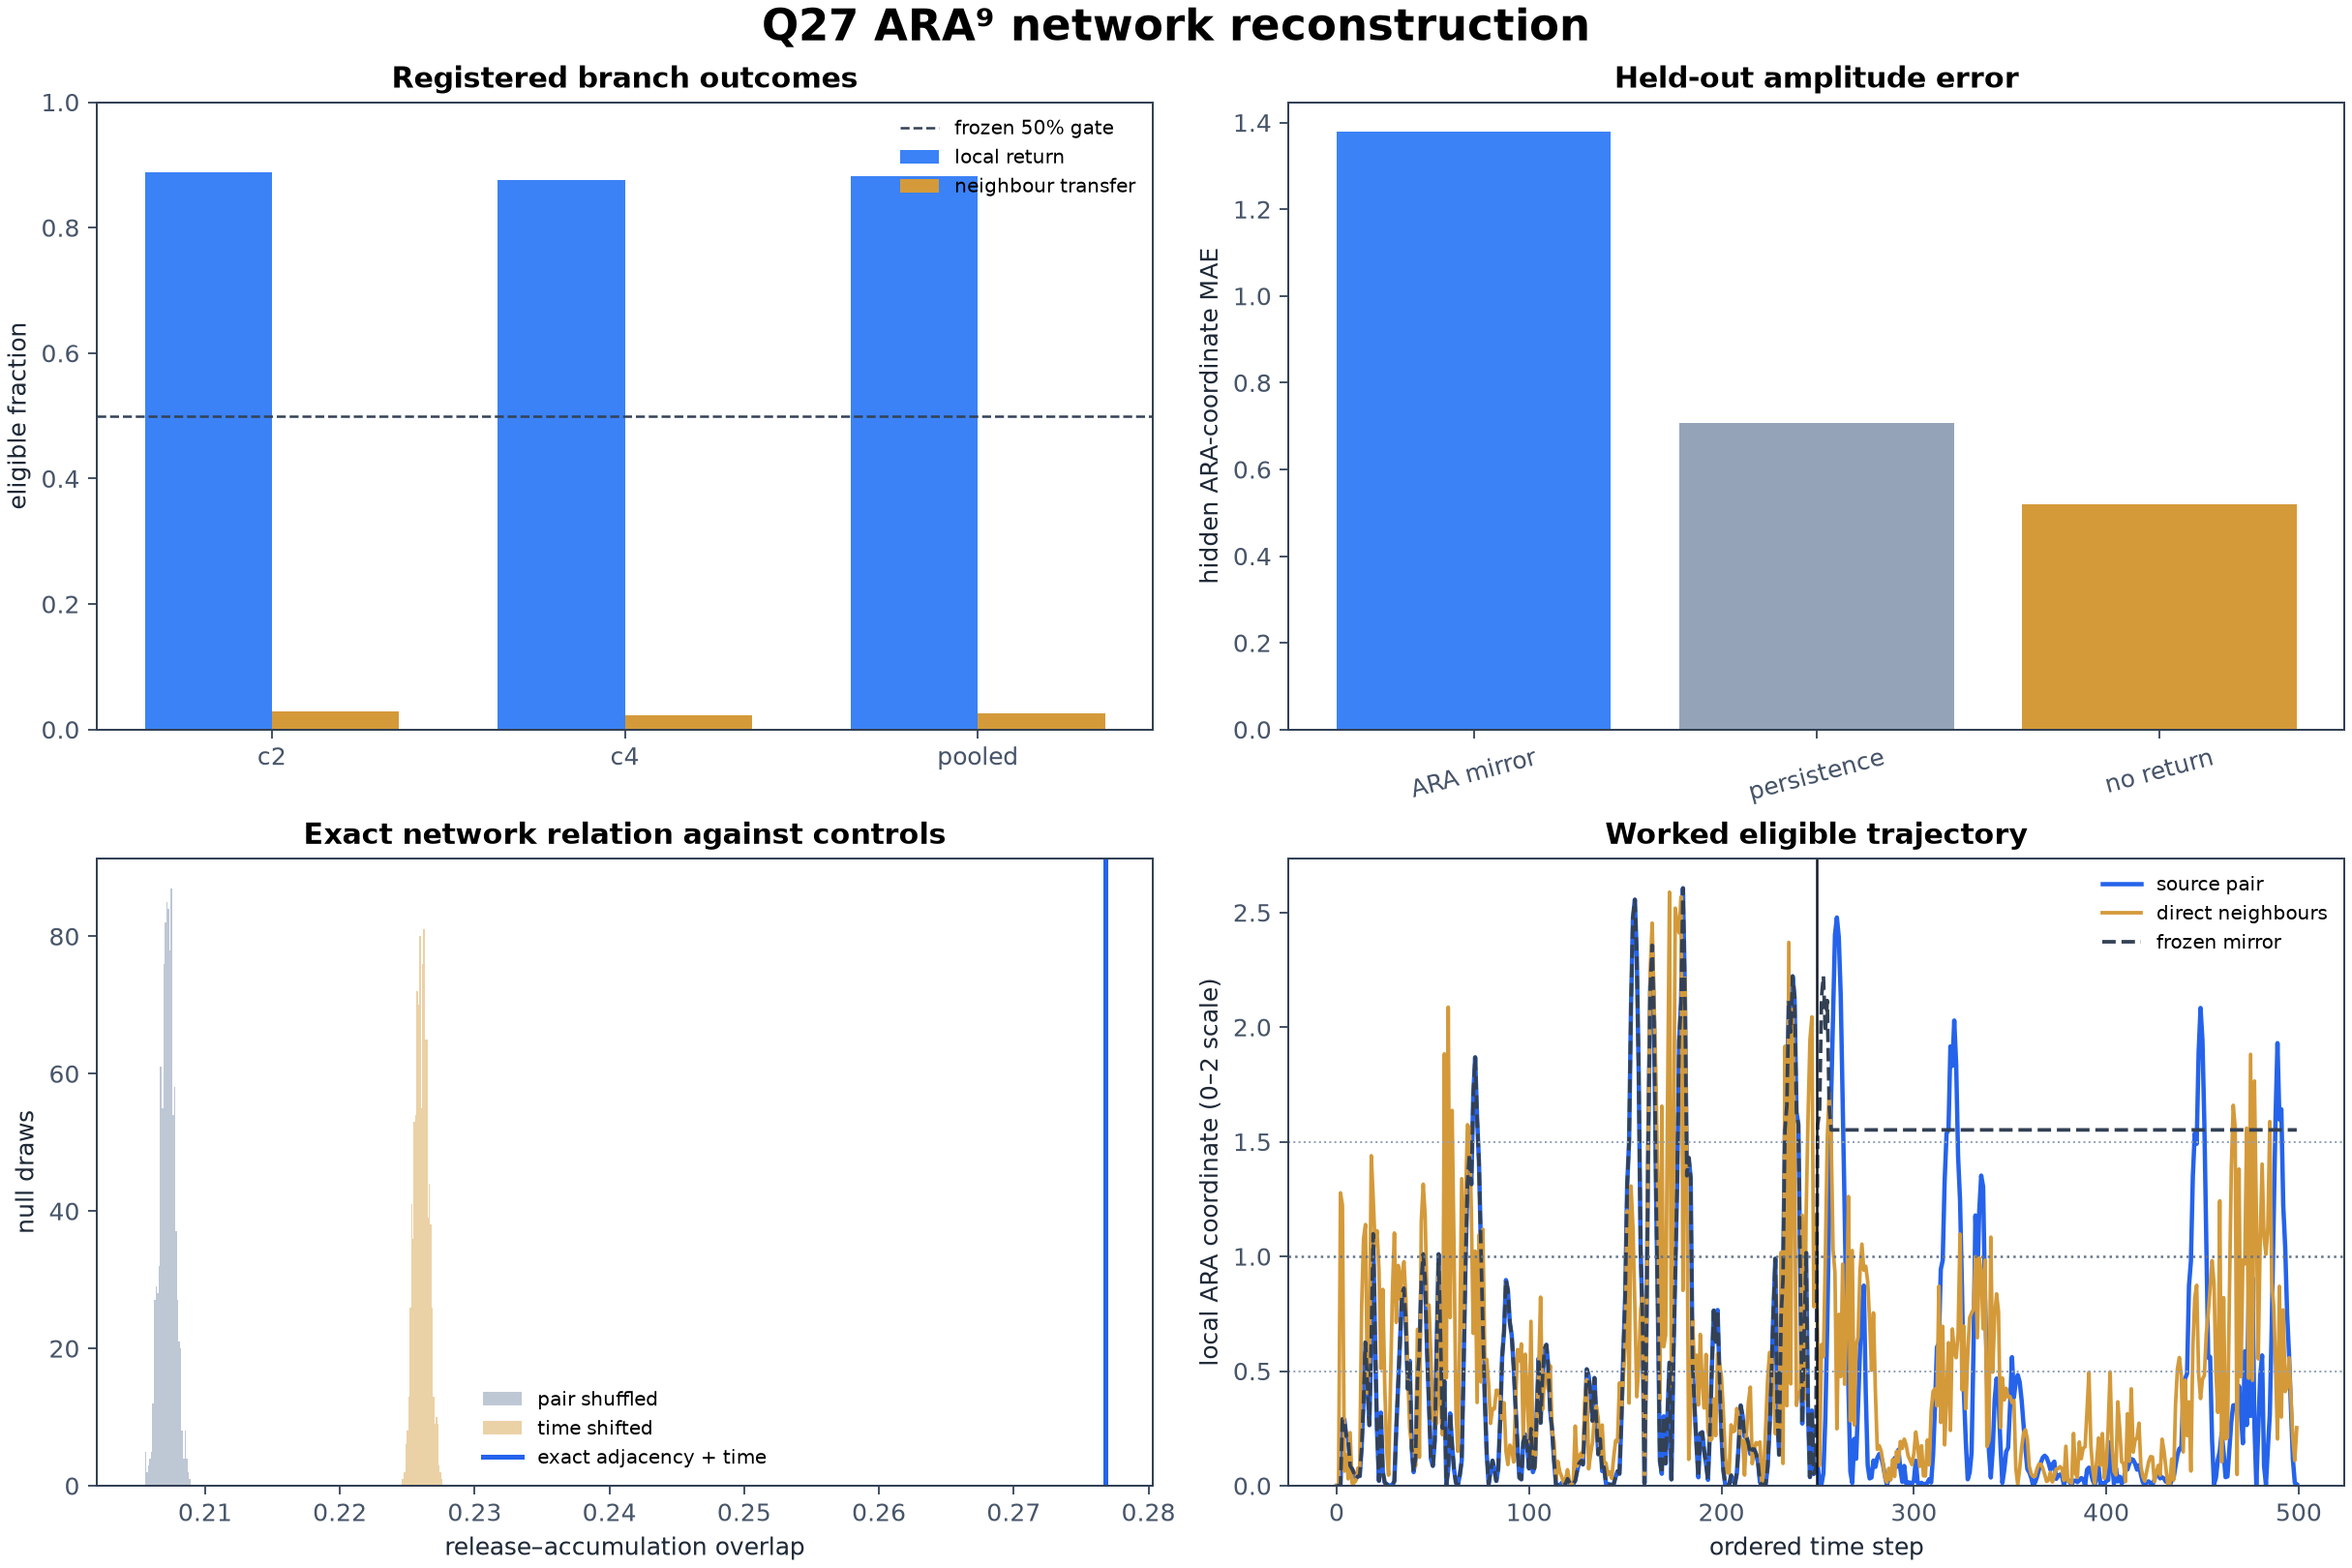

In [4]:
display(Image(filename=str(HERE / "Q27_ARA9_NETWORK_RECONSTRUCTION_GEOMETRY.png")))

### Gate interpretation

The visual recurrence alone is not enough to support the frozen parent-wave
claim. The registered model also required the return timing to be predictable
and the mirrored trajectory to beat simple controls; neither happened.

The network transfer control is narrower but genuine inside this simulator:
the source's release and its actual active neighbours' accumulation overlap
more than after either pair-label shuffling or circular time displacement.
That supports an ordered coupling relation, not the stronger claim that a
single neighbour becomes a crest-level Phase-B recipient.

In [5]:
for gate, passed in results["gates"].items():
    print(f"{gate:42s} {'PASS' if passed else 'FAIL'}")

D1_archive_md5                             PASS
D2_100x500_each_stratum                    PASS
D3_all_66_pairs                            PASS
D4_sampled_physical_matrices               FAIL
D5_freeze_precedes_numerical_read          PASS
R1_at_least_30_sources_20_trials           PASS
R2_local_reconstruction_50pct              PASS
R3_timing_hit_50pct                        FAIL
R4_mirror_beats_both_controls              FAIL
R5_bootstrap_95pct_both                    FAIL
B1_direct_neighbour_crest_50pct            FAIL
B2_exact_adjacency_95pct                   PASS
B3_exact_time_95pct                        PASS
B4_split_half_same_advantage               PASS
O1_stable_flips_50pct                      FAIL


## Takeaways

### ARA reading

The ARA cut reliably exposes a common local closure sequence and preserves
enough relational information to identify a real source-to-neighbour transfer
structure. But the larger motion is not a simple symmetric x2 resonance clock,
and the registered transfer does not close as one dominant neighbour crest.
The next ARA test should model a distributed, delayed coupling web rather than
promoting this weaker overlap result into the failed stronger branch.

### Established-physics reading

The dataset consists of simulated reduced two-qubit density-matrix trajectories
from larger unitary networks. Correlations can leave one reduced pair and
spread among several adjacent relations without appearing as a single
recipient's large peak. Q27's control result is compatible with that distributed
network behaviour.

### Evidence boundary

This is a checksum-locked test on complete public simulated data. It does not
yet demonstrate a new quantum law, a hardware effect, or universal fractality.

## Reproduction

From `analysis/quantum`:

```powershell
python q27_ara9_network_reconstruction_test.py all --workers 6
python q27_ara9_network_reconstruction_validate.py
python q27_build_notebook.py
```

If absent, the main runner automatically downloads and verifies the frozen
Zenodo archive before extracting it. The source and derived cache are excluded
from Git because they are large and reproducible.